In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_2009 = pd.read_excel(
    "../data/online_retail.xlsx",
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    "../data/online_retail.xlsx",
    sheet_name="Year 2010-2011"
)

df = pd.concat([df_2009, df_2010], ignore_index=True)

print(df.shape)

(1067371, 8)


In [16]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
 8   Revenue      779425 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 59.5+ MB


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

In [17]:
df.duplicated().sum()
df[df.duplicated()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue


In [18]:
df[df["Invoice"] == 489517]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
361,489517,21705,BAG 500g SWIRLY MARBLES,1,2009-12-01 11:34:00,1.65,16329.0,United Kingdom,1.65
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75
364,489517,16207A,PINK STRAWBERRY HANDBAG,2,2009-12-01 11:34:00,2.95,16329.0,United Kingdom,5.90
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75
366,489517,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,2009-12-01 11:34:00,2.95,16329.0,United Kingdom,2.95
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,7.80
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,5.10
369,489517,21584,RETRO SPOT SMALL TUBE MATCHES,20,2009-12-01 11:34:00,1.65,16329.0,United Kingdom,33.00
370,489517,20972,PINK CREAM FELT CRAFT TRINKET BOX,1,2009-12-01 11:34:00,1.25,16329.0,United Kingdom,1.25


In [19]:
#Clean Data#
# Remove missing Customer IDs
df = df.dropna(subset=["Customer ID"])

# Remove cancelled orders
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove negative or zero quantities
df = df[df["Quantity"] > 0]

# Remove zero prices
df = df[df["Price"] > 0]

# Remove exact duplicate transactions
df = df.drop_duplicates()

In [20]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


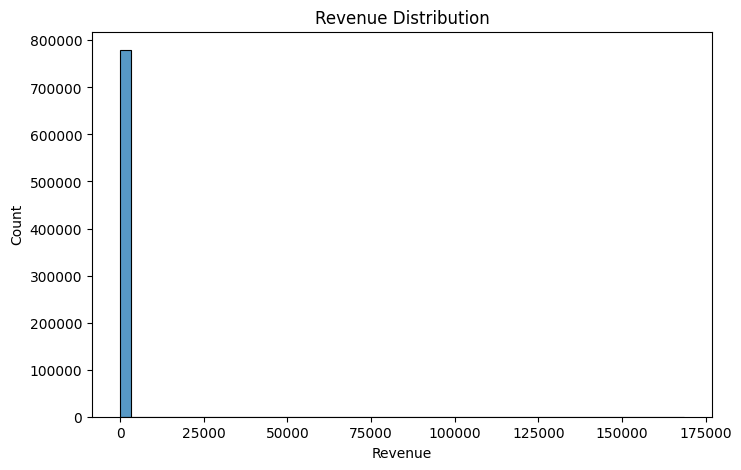

In [21]:
#Sales distribution

df["Revenue"] = df["Quantity"] * df["Price"]

plt.figure(figsize=(8,5))

sns.histplot(
    df["Revenue"],
    bins=50
)

plt.title("Revenue Distribution")
plt.show()

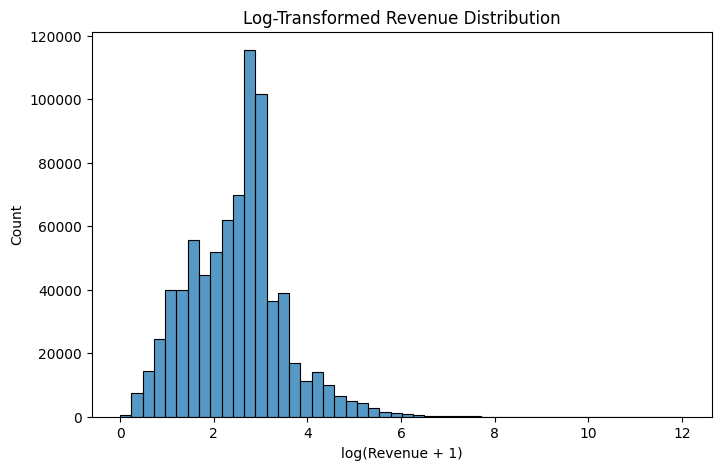

In [22]:
#Sales distribution Log Transformed
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df["Revenue"]),
    bins=50
)

plt.title("Log-Transformed Revenue Distribution")
plt.xlabel("log(Revenue + 1)")
plt.show()

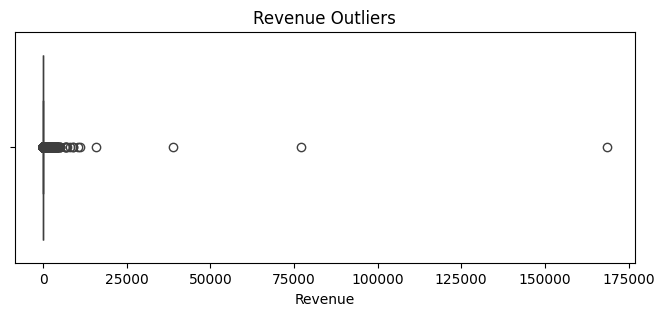

In [23]:
#Sales distribution Box Plot

plt.figure(figsize=(8,3))

sns.boxplot(
    x=df["Revenue"]
)

plt.title("Revenue Outliers")
plt.show()

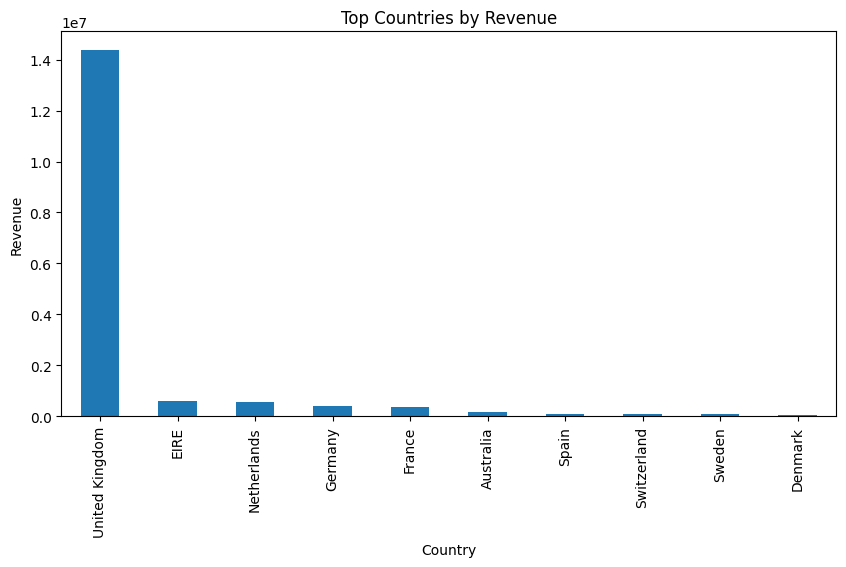

In [24]:
#Top Countries

country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

country_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

In [25]:
#Top Products

top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Revenue, dtype: float64

In [26]:
#Customer Count
df["Customer ID"].nunique()

5878

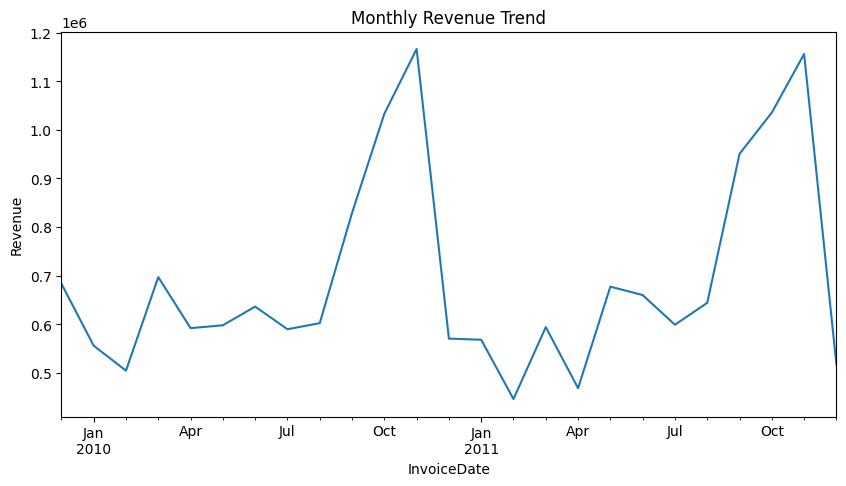

In [27]:
#Monthly Sales Trend

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_sales = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_sales.plot(
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

In [28]:
#Summary

print("Rows:", len(df))
print("Customers:", df["Customer ID"].nunique())
print("Orders:", df["Invoice"].nunique())
print("Revenue:", df["Revenue"].sum())

Rows: 779425
Customers: 5878
Orders: 36969
Revenue: 17374804.268


In [30]:
df.to_csv("../data/online_retail_cleaned.csv", index=False)